# Kalshi MLS Betting Model — Summary

A data-science pipeline that trains models on historical MLS matches to estimate
match-outcome probabilities, then compares them against Kalshi contract prices to
look for positive-EV bets in the regions where Kalshi is known to be mispriced
(the favorite–longshot bias documented in Bürgi, Deng & Whelan, *"Makers and
Takers"*, 2025 — see `docs/makers-and-takers-kalshi.pdf`).

This notebook is a narrated tour of what the pipeline in `src/` produced. It reads
already-computed artifacts from `data/processed/` and `reports/figures/` rather
than re-running the full pipeline (which hits three live APIs and a scraper) —
see `README.md` to reproduce end to end.

## 1. Data

- **American Soccer Analysis** (`itscalledsoccer`, free, no key): 31 MLS teams, 5,762
  completed games (2013–2026), 3,556 players, ~38.7k per-player-per-game stat rows
  (2023–2026).
- **Kalshi public API** (no key needed for market data): confirmed `KXMLSGAME`
  per-game markets exist (three binary contracts per game: home / away / tie).
  336 markets, 59k hourly candlesticks. Kalshi's MLS markets only have a few weeks
  of history at build time, so only **66 of the 5,762 ASA games** currently have a
  real resolved Kalshi price — that sample-size ceiling matters for everything in
  §4 below.
- **Rotowire injury feed** (`/soccer/tables/injury-report.php?league=MLS`): one
  timestamped snapshot so far, 133 rows, 88% fuzzy-matched to ASA player IDs.
  Injury *availability-loss* features are deferred until snapshot history
  accumulates (see the leakage rule in `PLAN (2).md` §3.4) — only the
  `injury_data_available` flag is live today.

In [1]:
import pandas as pd
from pathlib import Path
from IPython.display import Image, display

PROC = Path("../data/processed")
FIGS = Path("figures")
pd.set_option("display.max_columns", 20)

## 2. Models

Two models, both on a chronological (never shuffled) train/test split, scoped to
the 2023–2026 seasons where the richer features (goals-added, weather) are
populated:

1. **Multiple linear regression** → goal differential (`statsmodels` OLS,
   standardized features, VIF-checked).
2. **Multinomial logistic regression** → P(home / draw / away) (`statsmodels`
   MNLogit for interpretable odds ratios + L2-regularized `sklearn` for
   calibration/backtesting).

MLR holdout RMSE: 1.779


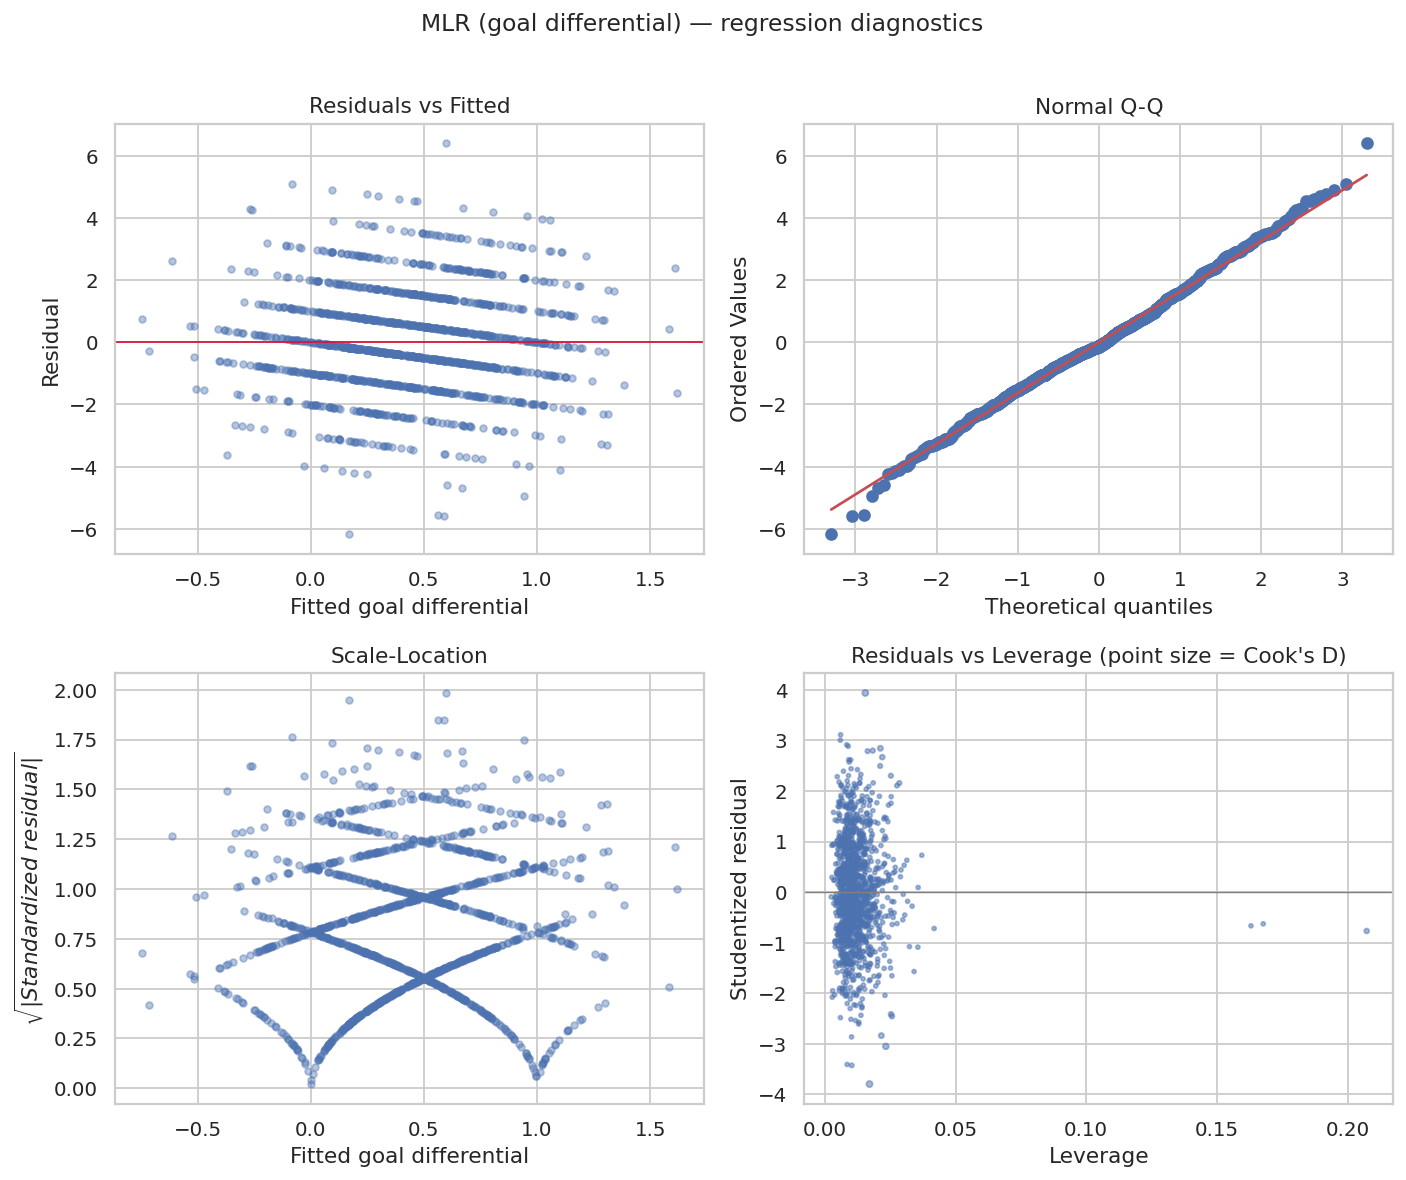

In [2]:
mlr_test = pd.read_csv(PROC / "mlr_test_predictions.csv")
rmse = ((mlr_test["goal_diff"] - mlr_test["pred_goal_diff"])**2).mean()**0.5
print(f"MLR holdout RMSE: {rmse:.3f}")
display(Image(str(FIGS / "mlr_diagnostics_4panel.png")))

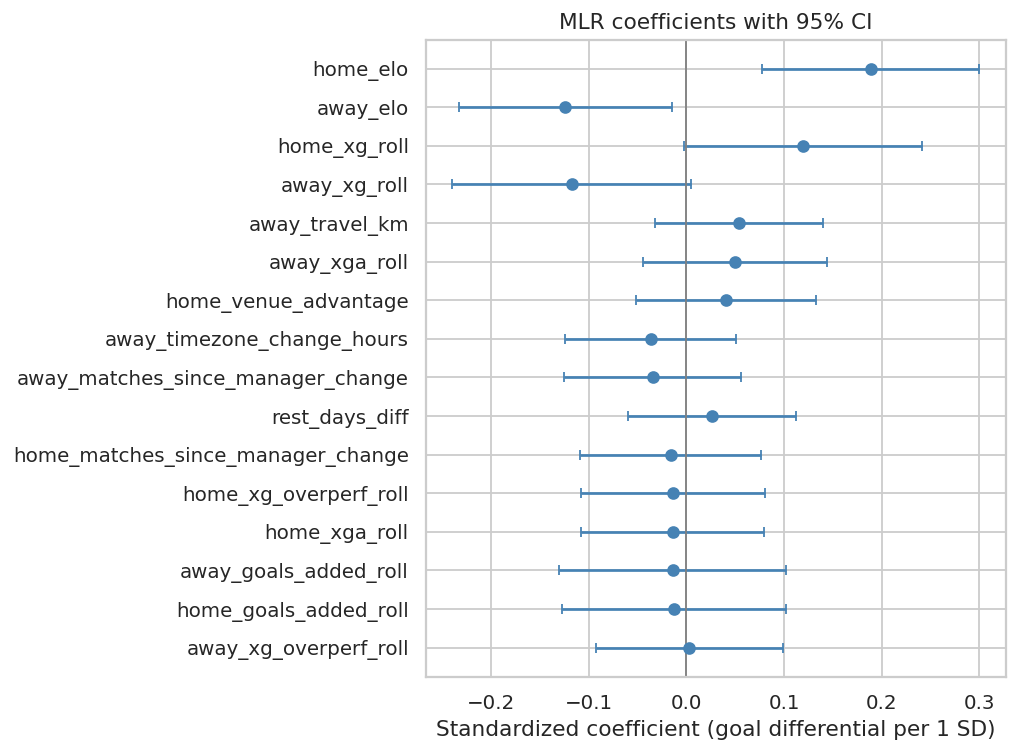

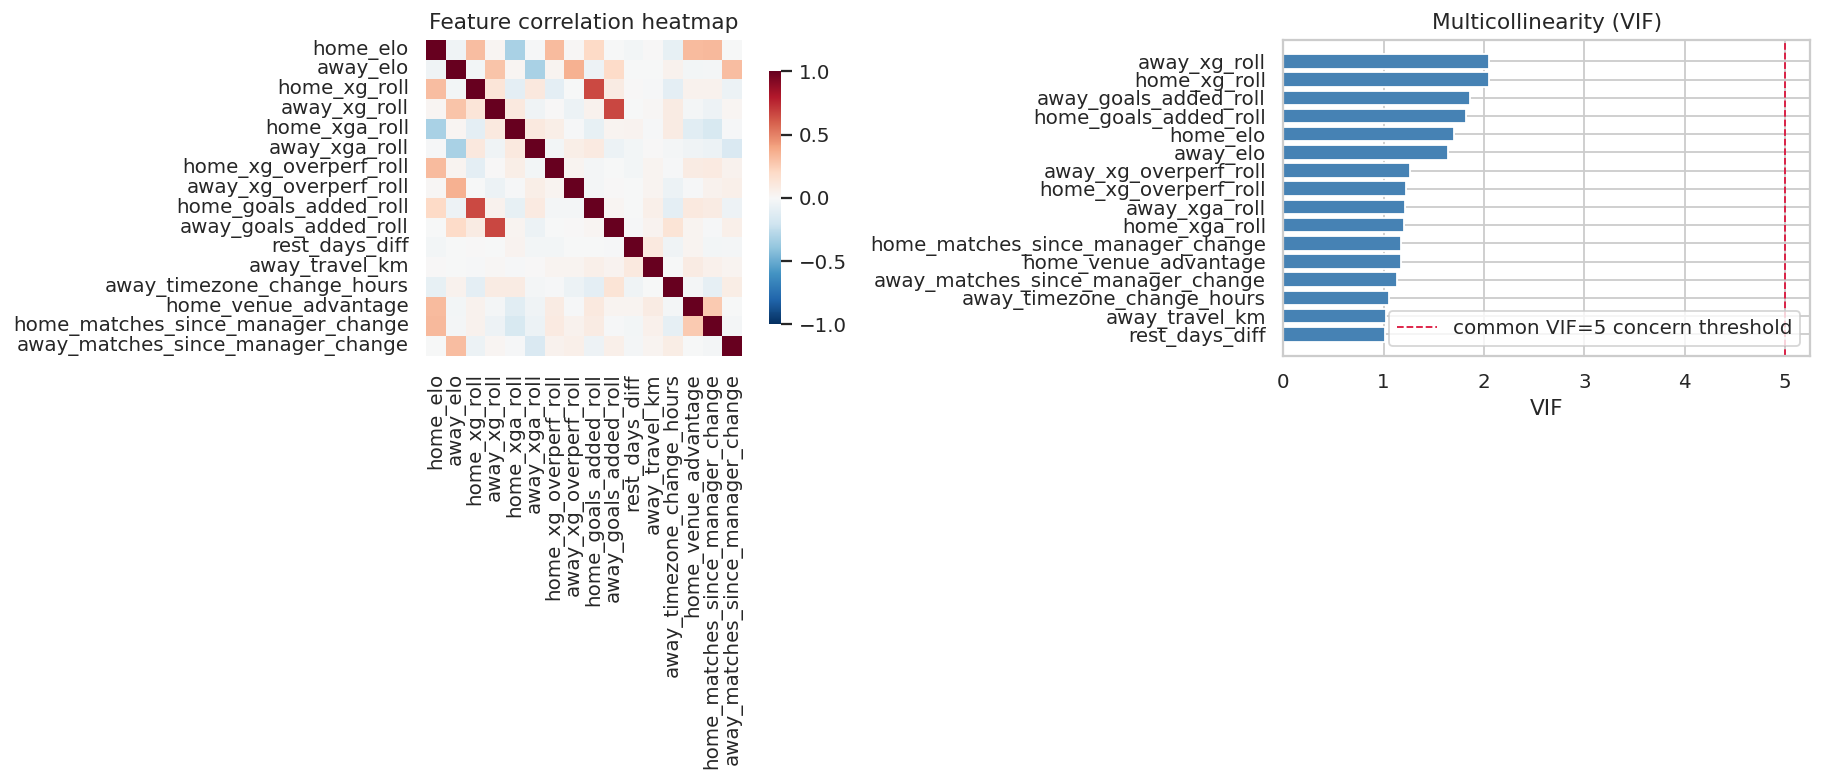

In [3]:
display(Image(str(FIGS / "mlr_coefficient_plot.png")))
display(Image(str(FIGS / "mlr_correlation_vif.png")))

R² on goal differential is low (~0.05) — expected for soccer, where scoring is
high-variance and pre-match features only explain a modest share of outcomes. VIFs
are all comfortably under 5 (max ~2.1), so multicollinearity isn't distorting the
coefficients. Elo and rolling xG are the only features that clear conventional
significance.

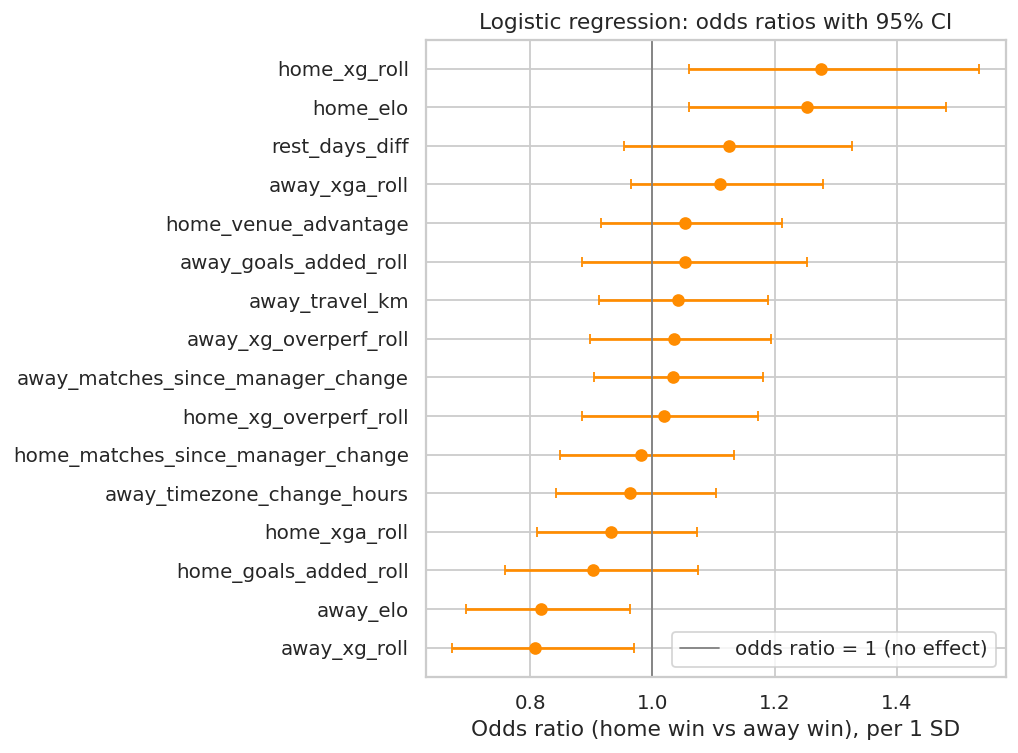

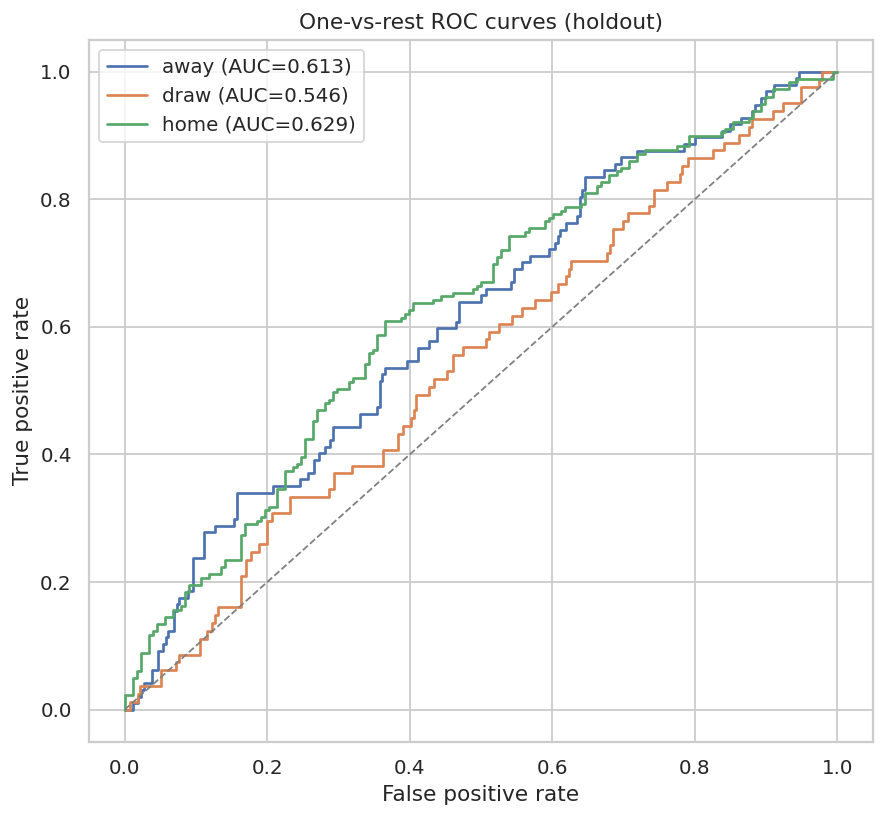

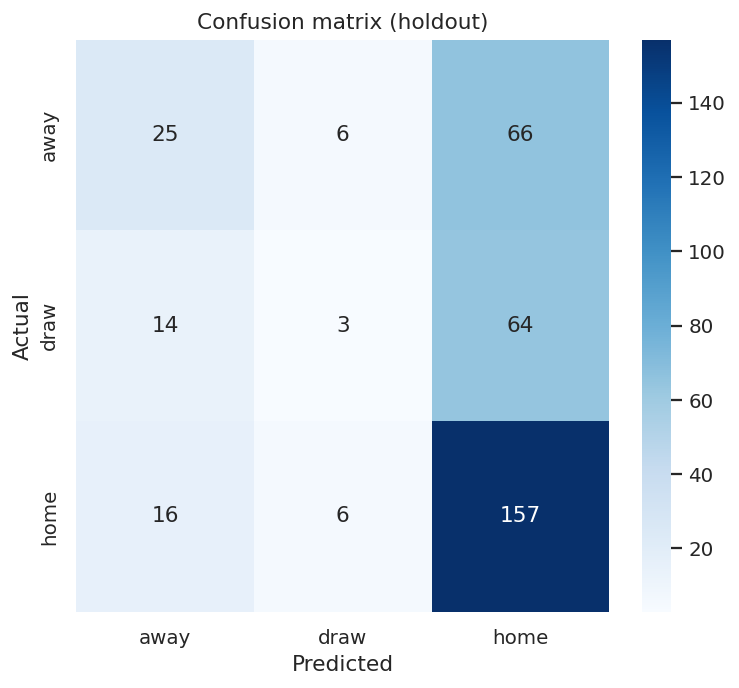

In [4]:
logistic_test = pd.read_csv(PROC / "logistic_test_predictions.csv")
display(Image(str(FIGS / "logistic_odds_ratio_plot.png")))
display(Image(str(FIGS / "logistic_roc_curves.png")))
display(Image(str(FIGS / "logistic_confusion_matrix.png")))

Holdout accuracy is 51.8% (3-class; home win is the plurality outcome), with
one-vs-rest AUCs of 0.55–0.63. That's in line with published soccer outcome models
using only pre-match features — nobody is beating soccer's irreducible randomness
with a handful of rolling stats.

## 3. Calibration

`calibrate.py` splits the holdout in half: the first half fits isotonic and
Platt/sigmoid calibration, the second half is an untouched final evaluation set.

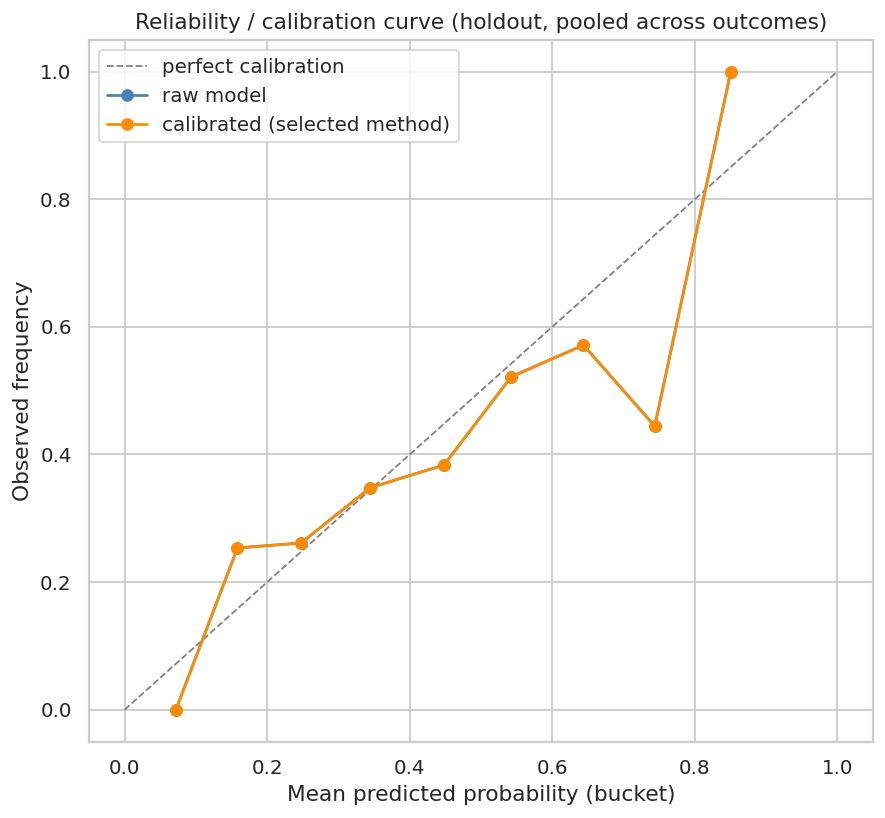

In [5]:
display(Image(str(FIGS / "reliability_curve.png")))

**Honest finding:** at only ~178 calibration rows, neither isotonic (Brier
0.669) nor Platt scaling (0.644) beat the raw, uncalibrated probabilities (Brier
0.641) on the final holdout — isotonic regression in particular overfits a
calibration set this small. The pipeline picks whichever method actually wins
rather than assuming calibration always helps, and falls back to raw
probabilities here. That's why the "raw" and "calibrated" lines in the reliability
curve above sit on top of each other.

## 4. The Kalshi edge, in our own data

The favorite–longshot bias from the paper, replicated directly on our 180
(game, side) contract-outcome pairs that have a real, pre-kickoff Kalshi closing
price:

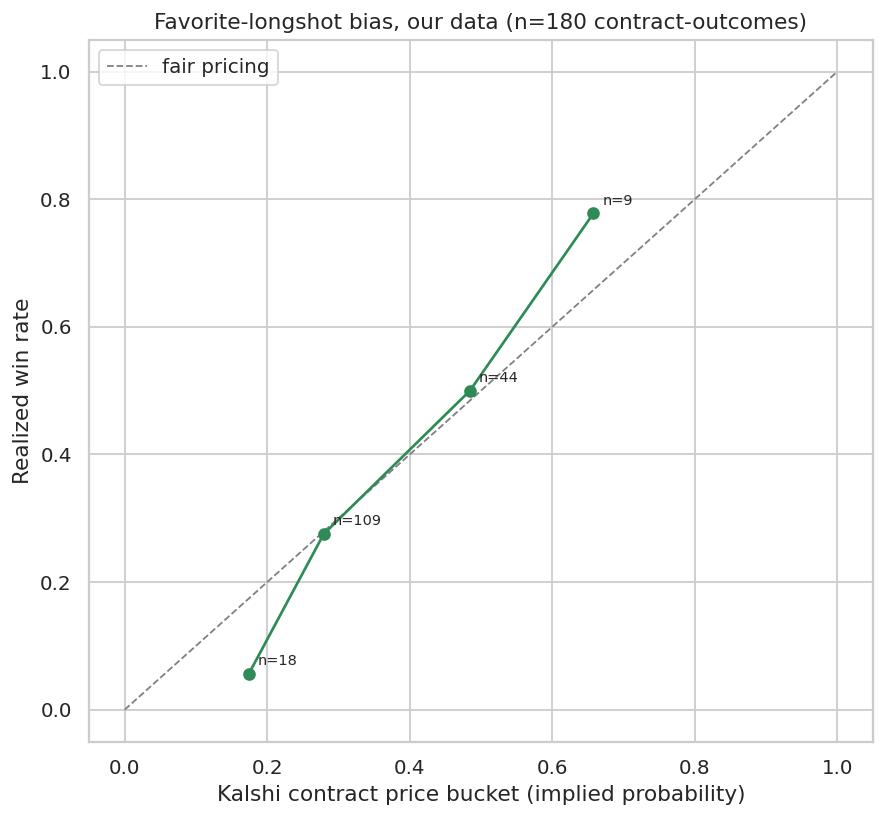

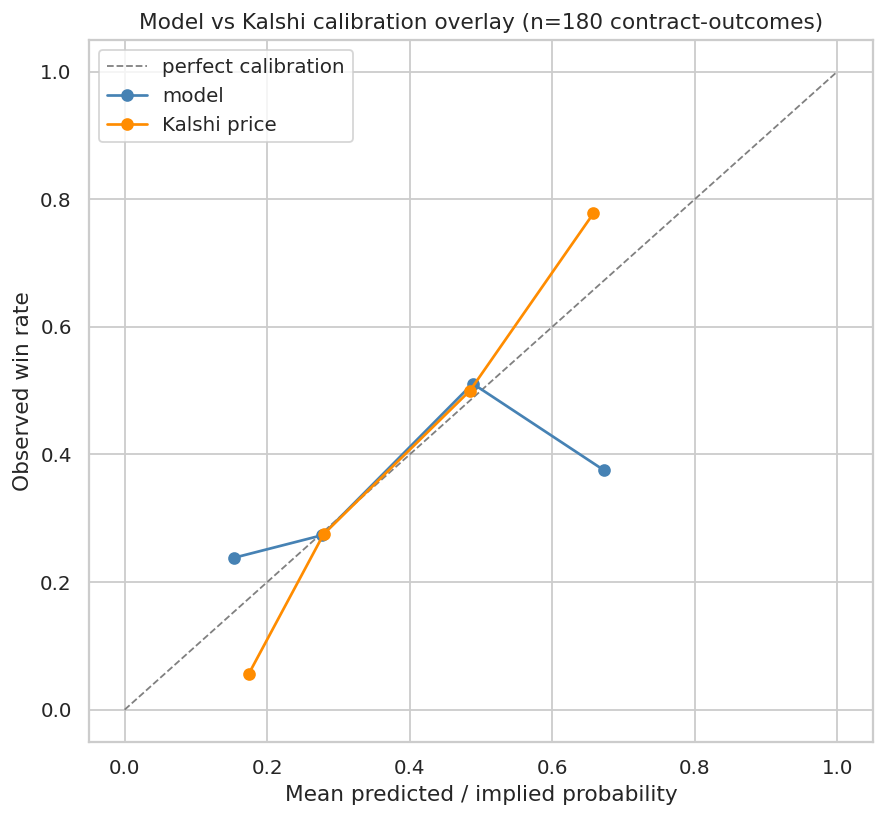

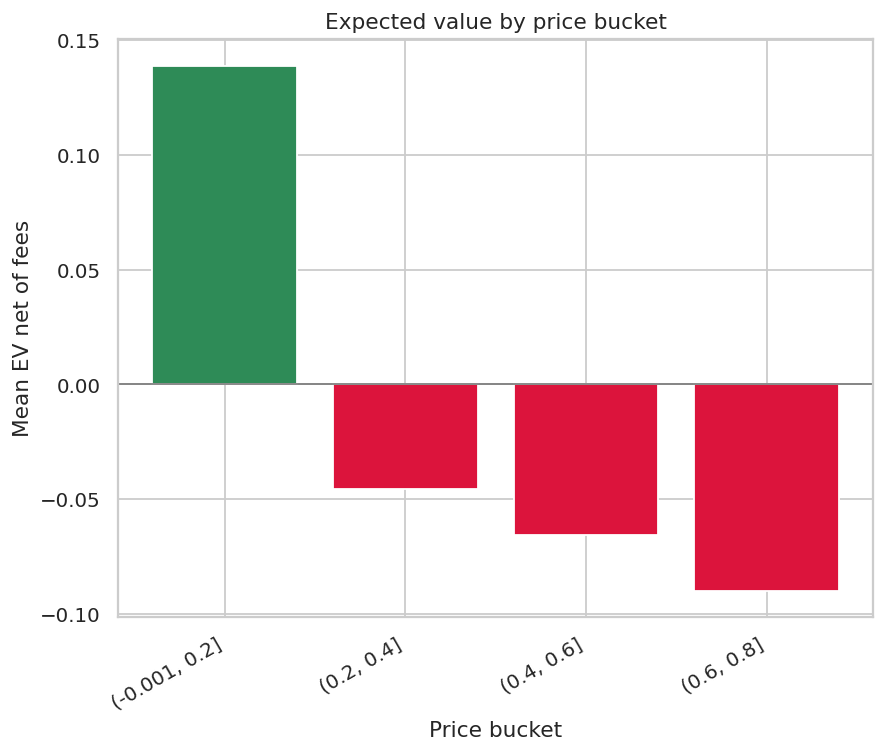

In [6]:
display(Image(str(FIGS / "favorite_longshot_bias.png")))
display(Image(str(FIGS / "calibration_overlay_model_vs_kalshi.png")))
display(Image(str(FIGS / "ev_by_price_bucket.png")))

The lowest price bucket (~18¢ average) realizes an 5.6% win rate — longshots
are overpriced, as the paper found. The highest populated bucket (~65¢ average,
n=9) realizes a 78% win rate — favorites underpriced, also consistent with the
paper. (Kalshi's MLS markets haven't yet listed anything in the 80–100¢ range in
our sample, so that bucket is empty.)

## 5. Backtest — read this with the sample size in mind

Filtering to the favorite side (price ≥ 60¢) and positive model EV net of an
approximated Kalshi fee:

,label,n_bets,hit_rate,total_staked,total_pnl,roi
0,Model (favorite + positive EV),3,0.333333,30.0,-14.042205,-0.468074
1,"Baseline (every favorite, no model filter)",10,0.700000,100.0,3.285854,0.032859


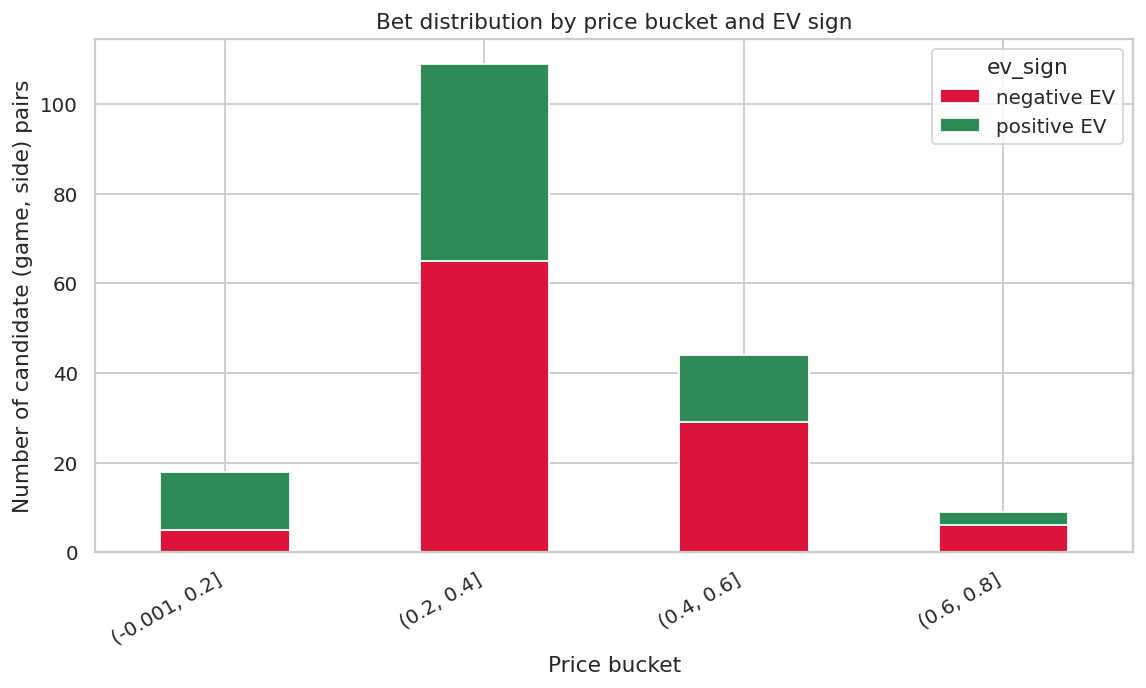

In [7]:
bt = pd.read_csv(PROC / "backtest_summary.csv")
display(bt)
display(Image(str(FIGS / "bet_distribution.png")))

| Strategy | n | hit rate | ROI |
|---|---|---|---|
| Model (favorite + positive EV) | 3 | 33% | −46.8% |
| Baseline (buy every favorite, no model) | 10 | 70% | +3.3% |

**n=3 is not a result, it's a coin flip.** The honest takeaway isn't "the model
lost money" — it's that Kalshi's MLS market history (a few weeks at build time)
hasn't yet produced enough resolved games to evaluate the model's bet selection at
all. The *baseline* — just buying every favorite-priced contract, no model
involved — already shows the paper's favorite-longshot bias paying off in our
data (+3.3% ROI, 70% hit rate on n=10), which is the more reliable of the two
findings here precisely because it doesn't depend on the model.

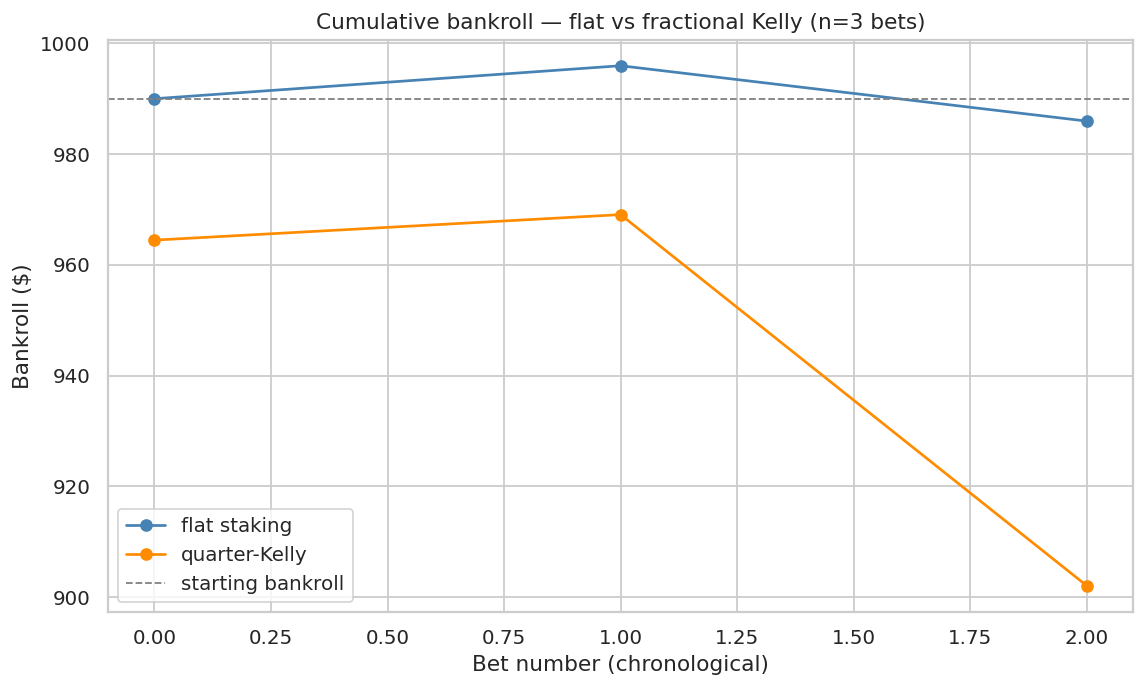

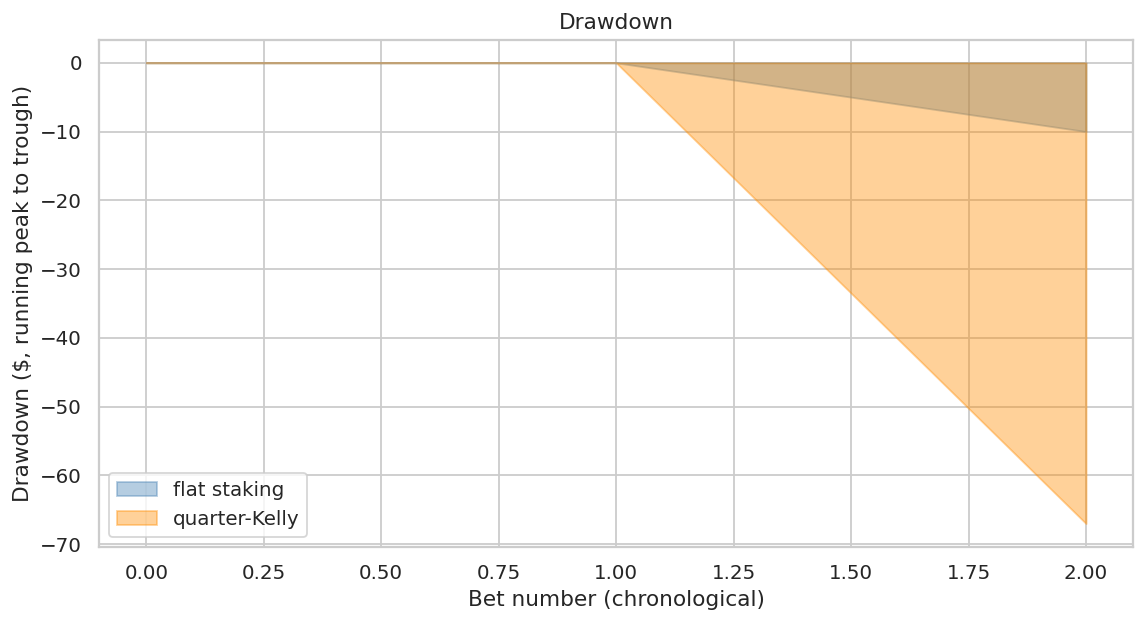

In [8]:
display(Image(str(FIGS / "bankroll_curve.png")))
display(Image(str(FIGS / "drawdown.png")))

## 6. What this means practically

- The pipeline is complete end to end: ingest → resolve → feature-engineer →
  model → calibrate → backtest → visualize, all re-runnable from `src/`.
- The two data-quality bugs caught during this build (a market-features
  leakage bug that used post-settlement instead of pre-kickoff prices, and a
  calibration method that silently would have hurt performance) are exactly the
  kind of thing that makes small-sample sports betting backtests unreliable if
  you don't check for them.
- The real constraint right now is **volume of resolved Kalshi history**, not
  model quality. As `ingest_kalshi.py` and `scrape_injuries.py` keep running over
  future MLS seasons, the 66-game resolved-market sample (and the injury-snapshot
  history) will grow, and `evaluate.py` / `bet_sim.py` should be re-run
  periodically rather than treated as a one-time result.
- Per the plan's own note: this is an educational project. The paper it's built
  on found Kalshi participants net-lose to fees, and any published edge tends to
  decay as others exploit it. Paper-trade forward before risking real money.